# 교보증권 사업 기준선과 민감도

## tl;dr

2026년 상반기 주식·해외선물은 수탁수수료의 **91.57%**다. 현재 중개 고객과 조달·운용 마진의 방어를 우선 검토하고 신규 STO 수익은 추가 고객·업무·가격·비용으로 검증한다. 이는 전략 가설이며 신사업 실적이 아니다.


## Context & Methods

공개 DART 반기보고서(2026-08-14, 접수번호 20260814003361)를 전사한 `data/public/kyobo_2026h1.json`을 사용한다. 손익은 2026년 1~6월, 비교는 전년 동기, 잔액은 6월 말. 연결·별도와 천원·백만원을 구별한다. 핵심 계산은 표준 라이브러리의 `analysis/business_baseline.py`이며 그림에 Matplotlib을 사용한다.

### Key Assumptions

중개 수수료 하락 5/10/20%는 거래량·고객 구성 고정 스트레스다. 신규 발행 1조원과 변동비 차감 후 추가 수수료 10/20/50bp도 임의 가정이다. 수익 예측·확률·규제 수수료가 아니다. 회사 고객·비용·가격 자료는 미확인.

[반기보고서 원문](https://dart.fss.or.kr/dsaf001/main.do?rcpNo=20260814003361)


## Data

### 1. 입력과 정의 확인


In [1]:
from pathlib import Path
import json, sys

candidates = (Path.cwd(), Path.cwd().parent)
root = next(p for p in candidates if (p / 'data/public/kyobo_2026h1.json').exists())
sys.path.insert(0, str(root / 'analysis'))
from business_baseline import calculate
source = json.loads((root / 'data/public/kyobo_2026h1.json').read_text(encoding='utf-8'))
metrics = calculate()
print('Period:', source['flow_period'])
print('Stock date:', source['stock_date'])
print(metrics['validation'])


Period: 2026-01-01/2026-06-30
Stock date: 2026-06-30
공시 전사값의 부문·수수료·이자·차입·대차 합계 및 백만원 반올림 대조 통과


## Results

### 2. 현재 수탁수수료의 구성

그림은 회사 전체 이익 비중이 아니라 별도 수탁수수료 안의 구성이다. 공시 백만원 반올림 값을 억원으로 환산한다.


In [2]:
for row in metrics['brokerage_fee_mix']:
    print(f"{row['category']}: {row['fee']:.2f}억원 / {row['share_pct']:.2f}%")
print(f"주식+해외선물: {metrics['stock_and_overseas_futures_share_pct']:.2f}%")


주식: 786.56억원 / 48.84%
해외선물: 688.28억원 / 42.73%
국내선물: 66.80억원 / 4.15%
장내옵션: 13.92억원 / 0.86%
기타증권: 55.08억원 / 3.42%
주식+해외선물: 91.57%


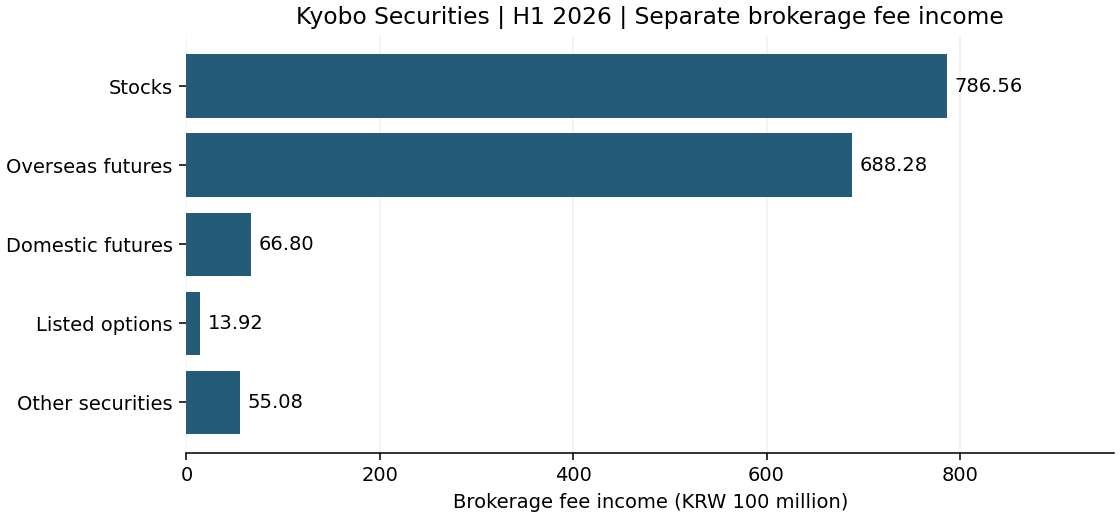

In [3]:
import matplotlib.pyplot as plt
rows = metrics['brokerage_fee_mix']
labels = ['Stocks', 'Overseas futures', 'Domestic futures', 'Listed options', 'Other securities']
values = [r['fee'] for r in rows]
fig, ax = plt.subplots(figsize=(8, 3.7), layout='constrained')
ax.barh(labels, values, color='#245B78')
ax.invert_yaxis()
ax.set_xlim(0, max(values) * 1.22)
ax.set_xlabel('Brokerage fee income (KRW 100 million)')
ax.set_title('Kyobo Securities | H1 2026 | Separate brokerage fee income')
for i, v in enumerate(values):
    ax.text(v + 8, i, f'{v:,.2f}', va='center', fontsize=10)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.set_axisbelow(True)
ax.grid(axis='x', alpha=.18)
plt.show()


### 3. 동기 비교와 스트레스 규모

아래 수수료·순이자·IB 부문익은 서로 다른 손익 층위다. 서로 더하지 않는다. 스트레스는 매출 변동 계산이며 최종 이익 감소액이 아니다.


In [4]:
print('순수수료 전년 동기비:', metrics['net_fee_growth_pct'], '%')
print('순이자 전년 동기비:', metrics['net_interest_growth_pct'], '%')
print('IB 부문 영업이익 전년 동기비:', metrics['ib_operating_profit_growth_pct'], '%')
for r in metrics['illustrative_brokerage_fee_pressure']:
    print(f"유효 수수료율 {r['effective_fee_reduction_pct']}% 하락 가정: 같은 반기 거래량에서 매출 {r['revenue_reduction_same_h1_volume']:.2f}억원 감소")
for r in metrics['illustrative_new_fee_scale']:
    print(f"신규발행 1조원, 추가 수수료 {r['incremental_fee_after_variable_cost_bp']}bp 가정: 고정비·위험비용 차감 전 공헌 {r['contribution_before_fixed_cost_and_risk']:.0f}억원")


순수수료 전년 동기비: 81.78 %
순이자 전년 동기비: -2.6 %
IB 부문 영업이익 전년 동기비: -10.82 %
유효 수수료율 5% 하락 가정: 같은 반기 거래량에서 매출 80.53억원 감소
유효 수수료율 10% 하락 가정: 같은 반기 거래량에서 매출 161.06억원 감소
유효 수수료율 20% 하락 가정: 같은 반기 거래량에서 매출 322.13억원 감소
신규발행 1조원, 추가 수수료 10bp 가정: 고정비·위험비용 차감 전 공헌 10억원
신규발행 1조원, 추가 수수료 20bp 가정: 고정비·위험비용 차감 전 공헌 20억원
신규발행 1조원, 추가 수수료 50bp 가정: 고정비·위험비용 차감 전 공헌 50억원


## Takeaways

현재 수탁수수료 일부의 압력이 소규모 신규 발행 서비스의 기여보다 클 수 있다. 기존 고객·본업을 방어하면서 반복 조달·판매·사후관리의 추가 손익을 확인한다. 원장 사용 자체의 대가 금지 예고안, 기존 수익 대체, 제휴비·고정비·위험비용을 반영해야 한다.

검증: 부문·수수료·이자·차입·대차 합계 및 수탁 표의 단위 반올림을 재계산했다. 전사값 원자료의 회계 타당성, 고객 유지율·가격·신사업 수익·기술효과를 검증한 것은 아니다.
